# Chaîne OSF CAPC-AC — Notebook 04 · Le skill brut des modèles (phase P2)

**Objectif :** mesurer ce que valent les modèles **avant toute correction**, et comprendre
chaque score assez bien pour pouvoir le défendre devant un utilisateur.

Pourquoi commencer par là ? Parce qu'une calibration ne se juge pas dans l'absolu : elle se juge
par rapport au modèle brut. Le *Draft Objective Seasonal Forecasting Framework* le demande deux
fois — au §3.3, pour décider quels modèles ont le droit d'entrer dans le multimodèle, et au §5,
pour publier la performance avec le produit. Les nombres de ce notebook sont donc à la fois un
diagnostic et une référence.

Plan :

1. la validation croisée LOYO, et pourquoi elle n'est pas une formalité ;
2. comment on fabrique un couple prévision/observation ;
3. les scores déterministes, lus sur des cartes ;
4. les scores probabilistes, et ce qu'ils ajoutent ;
5. le cas NMME : une moyenne d'ensemble n'est pas une probabilité ;
6. la vérification croisée Python ↔ R ;
7. les diagrammes de fiabilité et ROC, et comment les lire ;
8. l'éligibilité des modèles.

In [1]:
from pathlib import Path
import os
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

REPO = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
os.chdir(REPO)
from eccas_s2s.settings import load_cycle
from eccas_s2s.operations.skill_raw import skill_dir

cfg = load_cycle("config/cycle_202609.yaml")
OUT = skill_dir(cfg)
table = pd.read_csv(OUT / "skill_raw_summary.csv")
print(f"cycle {cfg.cycle_id}, initialisation {cfg.init_date.date()}")
print(f"{len(table)} lignes de score déjà calculées dans {OUT}")

cycle 202609, initialisation 2026-09-01
977 lignes de score déjà calculées dans /home/ludric/Downloads/SVM/Previsions_S2S/OUTPUTS_OSF/skill/202609/raw


## 1. LOYO : noter sans tricher

Un score n'a de sens que si la prévision n'a pas « vu » l'année qu'elle prévoit. Or les seuils
des catégories (terciles) et la climatologie de référence sont estimés **sur l'échantillon
lui-même**. Si l'on garde l'année notée dans cet échantillon, elle contribue à son propre seuil,
et le score obtenu est optimiste.

La chaîne applique donc la validation croisée **leave-one-year-out** (décision D10) : pour noter
l'année *y*, tous les seuils sont recalculés sur les 23 autres années. `eccas_s2s.validate.cv` le
fait sans boucle Python, en retirant l'année du calcul de façon vectorisée.

Sur une série de 24 valeurs, retirer une année déplace le tercile de un à deux pour cent — peu de
chose en apparence. La section 2 mesure ce que cela change sur le score lui-même, sur les vraies
données d'ECMWF.

In [2]:
from eccas_s2s.validate.cv import loyo_quantile

rng = np.random.default_rng(0)
serie = xr.DataArray(rng.gamma(2.0, 60.0, size=24),
                     dims="year", coords={"year": np.arange(1993, 2017)})

q_in = serie.quantile([1/3, 2/3])                       # seuils « en dedans »
q_loyo = loyo_quantile(serie, (1/3, 2/3))               # seuils LOYO, une valeur par année
print(f"seuils sur 24 ans     : {float(q_in[0]):.1f} et {float(q_in[1]):.1f} mm")
print(f"seuils LOYO (étendue) : {float(q_loyo.sel(quantile=1/3).min()):.1f}–"
      f"{float(q_loyo.sel(quantile=1/3).max()):.1f} et "
      f"{float(q_loyo.sel(quantile=2/3).min()):.1f}–{float(q_loyo.sel(quantile=2/3).max()):.1f} mm")

seuils sur 24 ans     : 58.5 et 119.0 mm
seuils LOYO (étendue) : 57.4–59.1 et 117.6–121.9 mm


## 2. Le couple prévision / observation

`eccas_s2s.validate.pairs.build_pairs` assemble, pour chaque année et chaque maille :

| champ | contenu |
|---|---|
| `ensmean`, `ens_sd` | moyenne et dispersion des membres (scores déterministes, CRPS) |
| `obs` | l'observation de la même période, sur la même grille |
| `obs_cat` | catégorie observée, définie par les **terciles de l'observation** (LOYO) |
| `prob` | probabilités BN/NN/AN, comptage des membres au-delà des **terciles du modèle** (LOYO) |

Deux climatologies différentes, et c'est volontaire. Une « saison excédentaire » est définie par
l'observation, jamais par le modèle. Mais les valeurs brutes d'un modèle sont biaisées : compter
ses membres au-delà des seuils *observés* mélangerait le biais du modèle et sa vraie information.
En comptant au-delà de ses propres terciles, on obtient la probabilité que le modèle exprime
réellement — la référence honnête que la calibration devra améliorer.

Chargeons les couples d'ECMWF pour la pluie (cela relit le hindcast : une trentaine de secondes).

In [3]:
from eccas_s2s.operations.skill_raw import prepare_pairs

pairs, periods = prepare_pairs(cfg, "c3s", "ecmwf", "precip", ["season"])
son = [p for p in periods if p.label(cfg.init_date.year).startswith("SON")][0]
print(f"{pairs.attrs['n_years']} années, {pairs.attrs['n_members']} membres, "
      f"période {son.label(cfg.init_date.year)}")

pt = dict(latitude=4.5, longitude=18.5, method="nearest")     # Bangui
ex = pairs.sel(period=son.key).sel(**pt)
tab = pd.DataFrame({
    "obs (mm)": ex["obs"].values.round(0),
    "cat. obs": [["BN", "NN", "AN"][int(c)] for c in ex["obs_cat"].values],
    "prév. moy. (mm)": ex["ensmean"].values.round(0),
    "p(BN)": ex["prob"].sel(category="BN").values.round(2),
    "p(NN)": ex["prob"].sel(category="NN").values.round(2),
    "p(AN)": ex["prob"].sel(category="AN").values.round(2),
}, index=ex["year"].values)
display(tab.head(8))
print(f"biais moyen du modèle brut en ce point : "
      f"{float((ex['ensmean'] - ex['obs']).mean()):.0f} mm par saison")

/home/ludric/anaconda3/envs/eccas-s2s/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1563: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,


24 années, 25 membres, période SON 2026


,obs (mm),cat. obs,prév. moy. (mm),p(BN),p(NN),p(AN)
1993,490.0,NN,544.0,0.68,0.20,0.12
1994,412.0,BN,624.0,0.12,0.28,0.60
1995,493.0,AN,581.0,0.28,0.40,0.32
1996,437.0,BN,579.0,0.28,0.40,0.32
1997,456.0,BN,598.0,0.20,0.40,0.40
1998,622.0,AN,596.0,0.20,0.32,0.48
1999,568.0,AN,559.0,0.44,0.36,0.20
2000,492.0,AN,579.0,0.32,0.28,0.40


biais moyen du modèle brut en ce point : 104 mm par saison


### Ce que LOYO change, mesuré

Refaisons le calcul **sans** retirer l'année notée — d'abord des deux côtés, puis d'un seul — et
regardons le RPS (l'erreur elle-même) autant que le RPSS (l'erreur comparée à la climatologie).

In [4]:
from eccas_s2s.operations import c3s_totals
from eccas_s2s.obs.regrid import match_model_grid
from eccas_s2s.validate.pairs import TERCILES
from eccas_s2s.validate.scores import tercile_skill

grille = pairs["obs"].isel(year=0, period=0, drop=True)
hind = match_model_grid(c3s_totals.load_totals(cfg, "ecmwf", "hindcast", "precip")
                        .sel(period=son.key).sel(year=pairs["year"]), grille).load()
obs_son = pairs["obs"].sel(period=son.key)
CAT = xr.DataArray(["BN", "NN", "AN"], dims="category", name="category")

# seuils « en dedans » : calculés sur les 24 années, année notée comprise
qm = hind.quantile(TERCILES, dim=["year", "number"], method="weibull")
qo = obs_son.quantile(TERCILES, dim="year", method="weibull")
prob_in = xr.concat([(hind < qm.isel(quantile=0, drop=True)).mean("number"),
                     ((hind >= qm.isel(quantile=0, drop=True))
                      & (hind < qm.isel(quantile=1, drop=True))).mean("number"),
                     (hind >= qm.isel(quantile=1, drop=True)).mean("number")], dim=CAT)
cat_in = xr.where(obs_son < qo.isel(quantile=0, drop=True), 0,
                  xr.where(obs_son >= qo.isel(quantile=1, drop=True), 2, 1))

prob_loyo, cat_loyo = pairs["prob"].sel(period=son.key), pairs["obs_cat"].sel(period=son.key)
lignes = []
for nom, pr, ct in [("LOYO des deux côtés (la chaîne)", prob_loyo, cat_loyo),
                    ("probabilités en dedans", prob_in, cat_loyo),
                    ("catégories observées en dedans", prob_loyo, cat_in),
                    ("tout en dedans", prob_in, cat_in)]:
    sc = tercile_skill(pr, ct)
    lignes.append({"variante": nom, "RPS": float(sc["rps"].median()),
                   "RPS climatologie": float(sc["rps_clim"].median()),
                   "RPSS": float(sc["rpss"].median())})
display(pd.DataFrame(lignes).set_index("variante").round(4))

/home/ludric/anaconda3/envs/eccas-s2s/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1563: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,


,RPS,RPS climatologie,RPSS
variante,,,
LOYO des deux côtés (la chaîne),0.2176,0.2222,0.0210
probabilités en dedans,0.2166,0.2222,0.0256
catégories observées en dedans,0.2119,0.2222,-0.0017
tout en dedans,0.2109,0.2222,0.0032


Le RPS — l'erreur elle-même — est **systématiquement plus faible quand on triche** : 0,2176
en LOYO, 0,2109 quand ni le modèle ni l'observation ne retirent l'année notée, soit 3 % d'erreur
en moins obtenus sans rien prévoir de mieux. C'est l'optimisme classique de la validation en
dedans, et c'est la raison d'être de la décision D10.

Le RPSS, lui, ne se déplace pas de façon aussi lisible : sa référence est le RPS de la prévision
climatologique, qui dépend **des mêmes catégories observées**. Changer la façon de définir les
catégories déplace donc le score et son étalon en même temps, et la médiane sur le domaine
mélange les deux mouvements — d'où la ligne « catégories observées en dedans », dont le RPS
s'améliore alors que le RPSS baisse.

La leçon n'est pas qu'une variante donne toujours un chiffre plus flatteur, mais qu'elles ne
répondent pas à la même question. Une seule répond à la question opérationnelle — *que vaudra
cette prévision sur une année que personne n'a encore vue ?* — et c'est celle que la chaîne
applique partout, des deux côtés. L'enjeu grandira en phase P3, où la calibration ajustera des
paramètres sur ces mêmes années.

Les probabilités ne sont jamais 0 ou 1 : 51 membres donnent une gradation fine. Le biais de
plusieurs dizaines de millimètres, lui, montre pourquoi les catégories du modèle ne peuvent pas
être définies avec les seuils observés.

## 3. Les scores déterministes

Ils portent sur la moyenne d'ensemble, comparée à l'observation :

* **corrélation de Pearson** : le modèle fait-il varier la pluie dans le bon sens d'une année à
  l'autre ? Elle ignore les biais d'échelle — un modèle deux fois trop humide mais bien corrélé
  garde 0,6. C'est précisément ce qu'une calibration peut corriger, d'où son rôle de critère
  d'éligibilité déterministe (§3.3) ;
* **biais** et **RMSE** : l'erreur en millimètres ;
* **MSESS** : l'erreur quadratique comparée à celle de la climatologie. Négatif = la moyenne
  climatologique fait mieux que le modèle brut, ce qui est courant tant que le biais n'est pas
  corrigé.

Les cartes ci-dessous viennent du fichier déjà écrit par `run_skill_raw.py`.

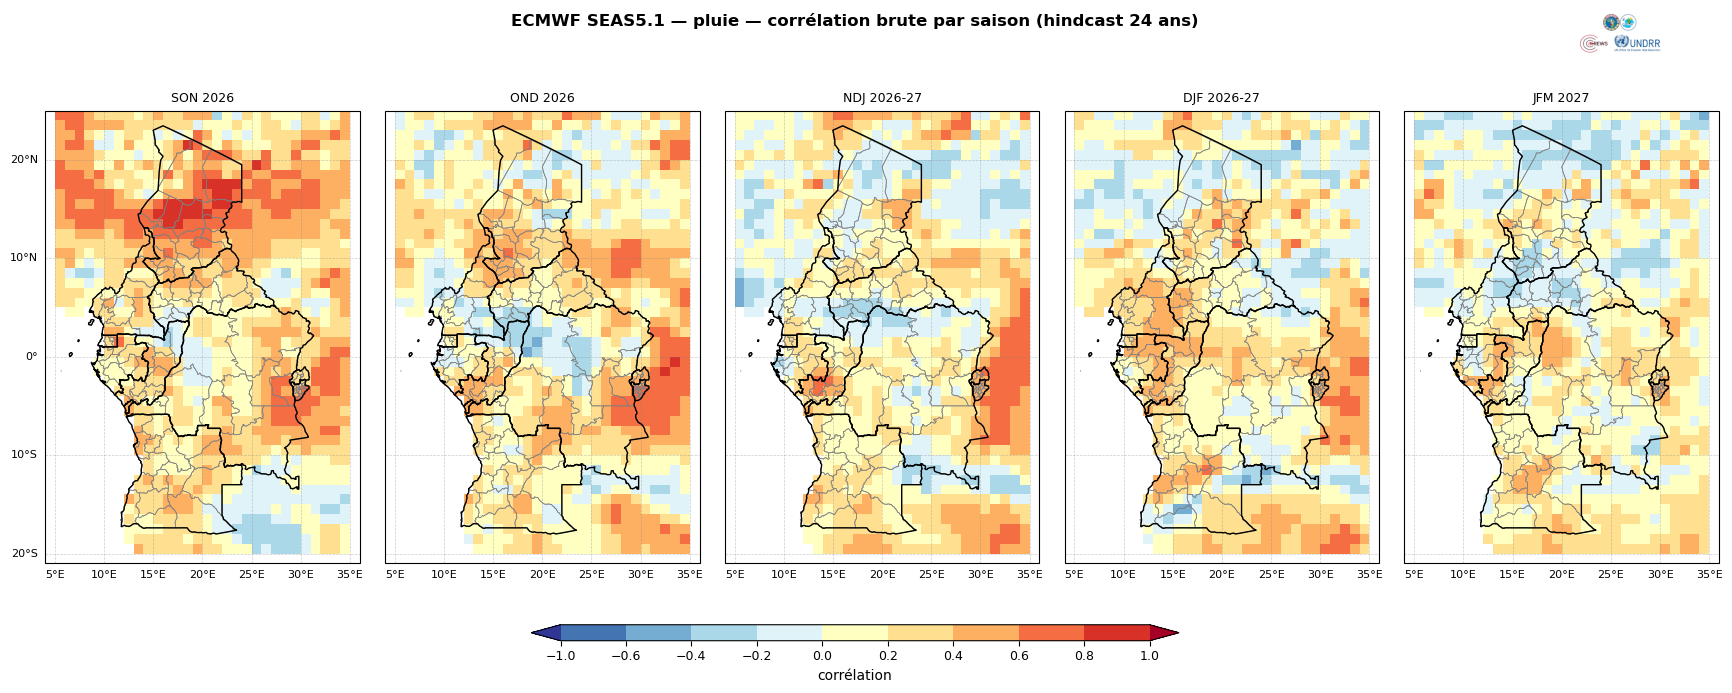

In [5]:
from eccas_s2s.viz.ceeac_maps import SKILL_STYLES, map_panel

maps = xr.open_dataset(OUT / "maps" / "c3s_ecmwf_precip_skill.nc")
saisons = [p for p in maps["period"].values if str(maps["scale"].sel(period=p).values) == "season"]
labels = [str(maps["label"].sel(period=p).values) for p in saisons]

fig = map_panel([maps["pearson"].sel(period=p) for p in saisons], labels,
                shapefile=cfg.raw["paths"]["shapefile"], logo=cfg.raw["paths"].get("logo"),
                extent=tuple(cfg.domains["domain"]["map_extent"]),
                cmap=SKILL_STYLES["pearson"]["cmap"], levels=SKILL_STYLES["pearson"]["levels"],
                cbar_label="corrélation", ncols=len(saisons),
                suptitle="ECMWF SEAS5.1 — pluie — corrélation brute par saison "
                         f"(hindcast {maps.attrs['n_years']} ans)")
plt.show()

La corrélation est correcte sur la première saison (SON, la saison en cours) et s'effondre
au-delà : c'est la limite de prévisibilité, et elle justifie que les produits à longue échéance
soient présentés avec leur score. Le tableau suivant met des nombres sur cette décroissance.

In [6]:
ecm = table[(table.model == "ecmwf") & (table.variable == "precip") & (table.scale == "season")]
display(ecm[["label", "pearson_domain_median", "msess_domain_median", "rpss_domain_median",
             "roc_AN_domain_median", "frac_pearson_positive"]]
        .rename(columns={"pearson_domain_median": "r (médiane domaine)",
                         "msess_domain_median": "MSESS", "rpss_domain_median": "RPSS",
                         "roc_AN_domain_median": "ROC (AN)",
                         "frac_pearson_positive": "part du domaine r > 0"})
        .round(3).to_string(index=False))

'      label  r (médiane domaine)  MSESS   RPSS  ROC (AN)  part du domaine r > 0\n   SON 2026                0.315 -3.598  0.020     0.641                  0.880\n   OND 2026                0.192 -1.537 -0.013     0.574                  0.787\nNDJ 2026-27                0.120 -1.586 -0.079     0.535                  0.682\nDJF 2026-27                0.144 -1.811 -0.085     0.527                  0.729\n   JFM 2027                0.084 -0.871 -0.085     0.516                  0.656'

## 4. Les scores probabilistes

* **RPS / RPSS** — le RPS somme, sur les catégories cumulées, l'écart entre probabilité prévue et
  réalité (0 ou 1) ; le RPSS le compare à la prévision climatologique (1/3, 1/3, 1/3). RPSS > 0
  signifie « mieux que dire *normale* ». Il est **normalisé par K−1** (convention de Wilks, celle
  du paquet R `verification`) ;
* **score de Brier** et son BSS, catégorie par catégorie ;
* **aire ROC** — la probabilité qu'une année où la catégorie s'est produite ait reçu une
  probabilité plus forte qu'une année où elle ne s'est pas produite. 0,5 = aucune discrimination.
  Elle est calculée sous forme exacte 2AFC (Mann-Whitney), sans classement en classes.

Le RPSS brut est souvent légèrement négatif : un modèle non calibré est **surconfiant**, il
annonce des probabilités trop tranchées. L'aire ROC, elle, reste supérieure à 0,5 : le signal
existe, il est seulement mal exprimé. C'est exactement l'écart que la calibration doit combler,
et c'est pourquoi la chaîne publie les deux.

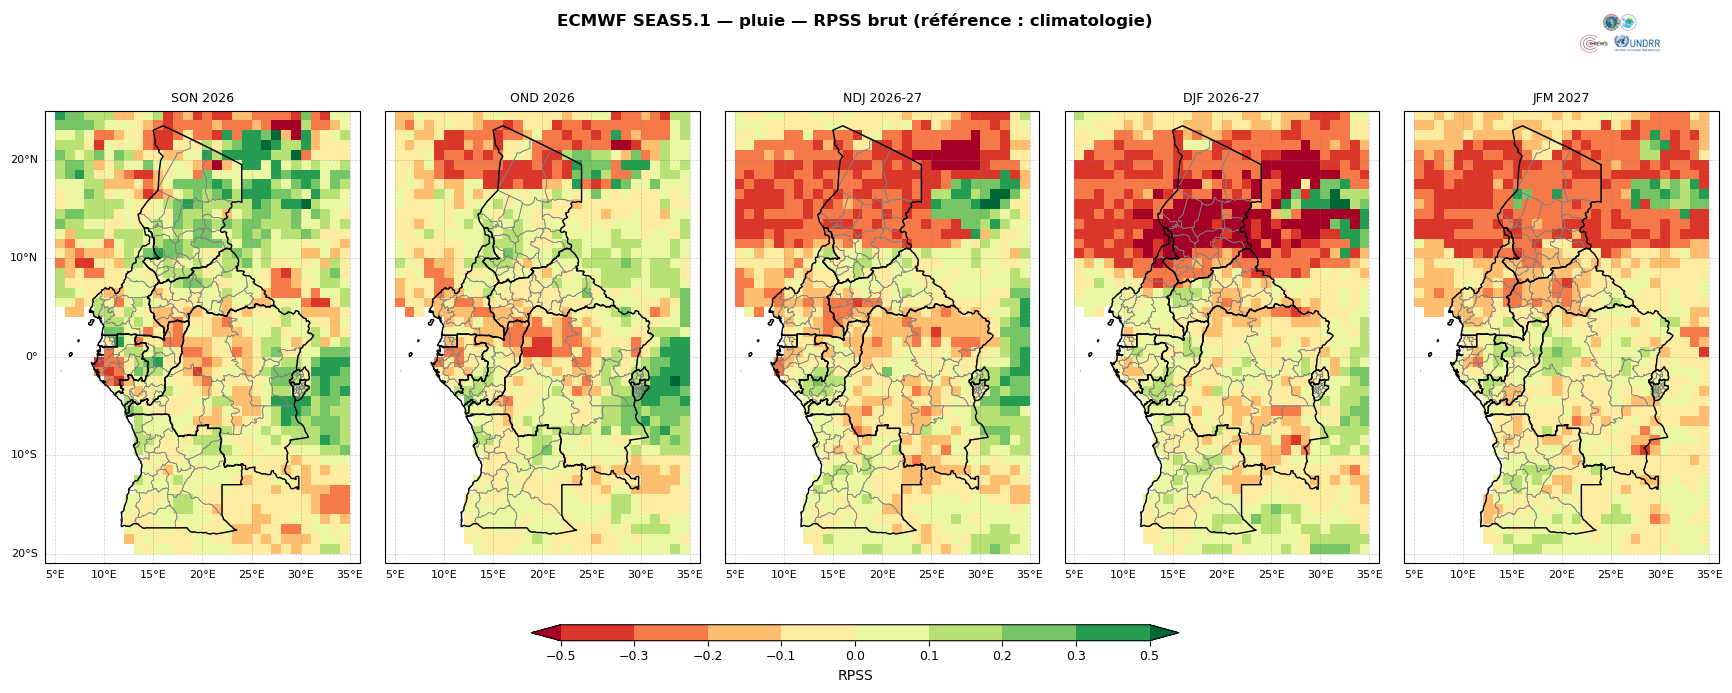

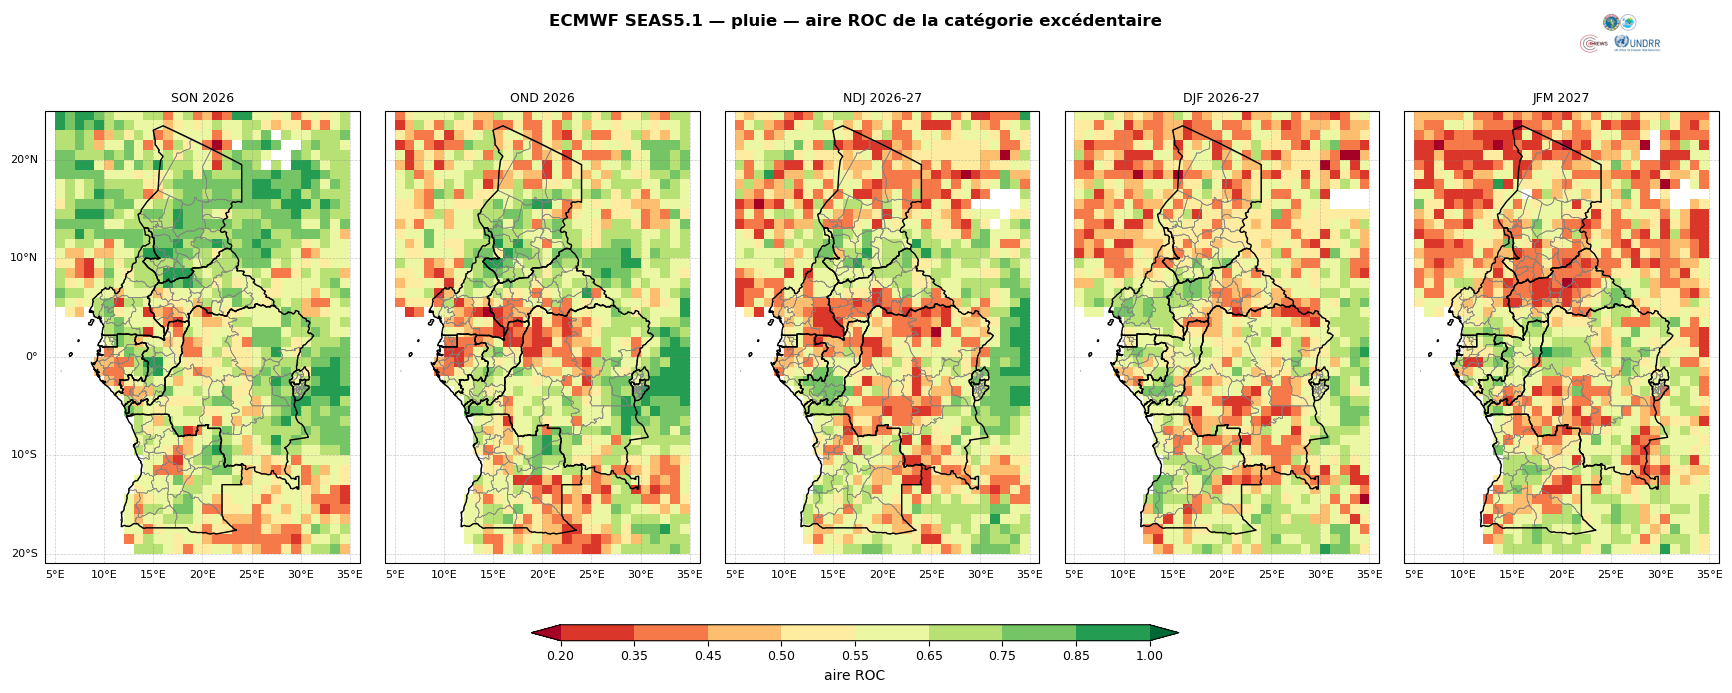

In [7]:
fig = map_panel([maps["rpss"].sel(period=p) for p in saisons], labels,
                shapefile=cfg.raw["paths"]["shapefile"], logo=cfg.raw["paths"].get("logo"),
                extent=tuple(cfg.domains["domain"]["map_extent"]),
                cmap=SKILL_STYLES["rpss"]["cmap"], levels=SKILL_STYLES["rpss"]["levels"],
                cbar_label="RPSS", ncols=len(saisons),
                suptitle="ECMWF SEAS5.1 — pluie — RPSS brut (référence : climatologie)")
plt.show()

fig = map_panel([maps["roc_area"].sel(period=p, category="AN") for p in saisons], labels,
                shapefile=cfg.raw["paths"]["shapefile"], logo=cfg.raw["paths"].get("logo"),
                extent=tuple(cfg.domains["domain"]["map_extent"]),
                cmap=SKILL_STYLES["roc_area"]["cmap"], levels=SKILL_STYLES["roc_area"]["levels"],
                cbar_label="aire ROC", ncols=len(saisons),
                suptitle="ECMWF SEAS5.1 — pluie — aire ROC de la catégorie excédentaire")
plt.show()

## 5. NMME : une moyenne d'ensemble n'est pas une probabilité

Les fichiers NMME du serveur NOAA/CPC contiennent la **moyenne des membres**, et rien d'autre.
On pourrait être tenté de traiter cette moyenne comme un ensemble d'un seul membre : la
probabilité vaudrait alors 1 pour la catégorie dans laquelle tombe la moyenne et 0 pour les deux
autres. Ce serait un artefact : un RPSS et une aire ROC calculés sur des 0/1 mesureraient la
qualité d'une *prévision catégorique déguisée*, et se compareraient à tort avec les probabilités
d'ECMWF.

La chaîne refuse donc de produire ces probabilités. `build_pairs` fournit à la place une
catégorie déterministe, `skill_raw` n'écrit que les scores déterministes, et l'éligibilité (§3.3)
ne retient pour ces modèles que le critère déterministe. NMME étant par ailleurs **mensuel**, il
n'est traité que sur les mois et les saisons (`SYSTEM_SCALES`). Ses probabilités ne pourront venir
que de la calibration de la phase P3.

In [8]:
nm = xr.open_dataset(OUT / "maps" / "nmme_CanESM5_precip_skill.nc")
print("variables NMME :", list(nm.data_vars))
print("variables C3S  :", list(maps.data_vars))

comp = (table[(table.variable == "precip") & (table.scale == "season")]
        .groupby(["system", "model"])["pearson_domain_median"].max().round(2)
        .sort_values(ascending=False))
print("\nMeilleure corrélation saisonnière (médiane domaine), pluie :")
print(comp.to_string())

variables NMME : ['n_years', 'bias', 'mae', 'rmse', 'rmse_clim', 'msess', 'pearson', 'acc', 'spearman']
variables C3S  : ['n_years', 'bias', 'mae', 'rmse', 'rmse_clim', 'msess', 'pearson', 'acc', 'spearman', 'rps', 'rps_clim', 'rpss', 'bss', 'roc_area']

Meilleure corrélation saisonnière (médiane domaine), pluie :
system  model       
c3s     ecmwf           0.31
nmme    NCAR_CESM1      0.29
        GEM5.2_NEMO     0.27
c3s     bom             0.26
        eccc            0.26
        ukmo            0.26
        cmcc            0.24
nmme    CanESM5         0.20
        CFSv2           0.19
        NASA_GEOS5v2    0.19
c3s     dwd             0.17
        meteo_france    0.17
nmme    NCAR_CCSM4      0.13


## 6. Python et R doivent dire la même chose

Les cartes sont calculées en Python, les scores de zone avec le paquet R `verification`, comme
dans la chaîne de référence du CAPC-AC. Deux implémentations valent mieux qu'une : la comparaison
a déjà révélé deux pièges, tous deux documentés par un test :

* le RPS de R est normalisé par K−1 ; sans cette normalisation, nos valeurs étaient doubles ;
* `brier()` classe par défaut les probabilités en dix classes, ce qui déplace le score ; la
  chaîne l'appelle donc **deux fois** — avec des seuils fins pour le score exact, et avec le
  classement par défaut pour la décomposition fiabilité / résolution / incertitude, qui n'a de
  sens que si une classe contient plusieurs prévisions (avec des seuils fins, chaque classe n'en
  contient qu'une : la fiabilité se confond alors avec le score et la résolution avec
  l'incertitude).

Les deux familles ne portent pas sur le même objet — la carte note chaque maille, R note l'indice
de zone — mais l'ordre de grandeur et le signe doivent concorder.

In [9]:
zone = OUT / "zones" / "c3s_ecmwf_precip" / "domain"
det = pd.read_csv(zone / "deterministic_scores.csv")
ter = pd.read_csv(zone / "tercile_scores.csv")
cat = pd.read_csv(zone / "category_scores.csv")
key = son.key

print("indice de zone (R) — saison", son.label(cfg.init_date.year))
print(det[det.period == key][["pearson", "rmse", "msess", "crps"]].round(3).to_string(index=False))
print(ter[ter.period == key][["rps", "rpss", "groc", "hss", "gerrity"]].round(3).to_string(index=False))
print(cat[cat.period == key][["category", "bss", "bs_reliability", "bs_resolution",
                              "roc_area", "roc_pvalue"]].round(3).to_string(index=False))
print("\ncartes (Python), médianes sur le domaine :")
print(f"  r = {float(maps['pearson'].sel(period=key).median()):.3f}   "
      f"RPSS = {float(maps['rpss'].sel(period=key).median()):.3f}   "
      f"ROC(AN) = {float(maps['roc_area'].sel(period=key, category='AN').median()):.3f}")

indice de zone (R) — saison SON 2026
 pearson   rmse   msess   crps
   0.543 50.563 -10.808 30.348
  rps  rpss  groc   hss  gerrity
0.196 0.118 0.677 0.312    0.281
category   bss  bs_reliability  bs_resolution  roc_area  roc_pvalue
      BN 0.089           0.024          0.043     0.711       0.053
      NN 0.042           0.005          0.010     0.711       0.053
      AN 0.146           0.033          0.065     0.727       0.040

cartes (Python), médianes sur le domaine :
  r = 0.320   RPSS = 0.021   ROC(AN) = 0.648


Les scores de zone sont plus élevés que la médiane des mailles, et c'est normal : la moyenne
spatiale annule une partie du bruit local, l'indice de zone est plus prévisible qu'une maille
isolée. Les deux chiffres répondent à deux questions différentes — « que vaut la prévision *ici* »
et « que vaut la prévision *pour la région* » — et la chaîne publie les deux.

## 7. Lire un diagramme de fiabilité et une courbe ROC

Ces deux figures sont tracées en R (`validate/zone_diagrams.R`), à partir des couples de **tous
les points de grille** de la zone. Ce regroupement est indispensable : avec 24 années seulement,
dix classes de probabilité contiendraient deux ou trois cas, et la fréquence observée ne pourrait
valoir que 0, 1/3, 1/2 ou 1. Il est légitime ici parce que l'événement est un tercile, dont la
fréquence de base vaut 1/3 en **chaque** maille par construction ; il ne le serait pas pour un
seuil en millimètres, qui est un non-événement au nord et une certitude au sud.

En contrepartie, les mailles voisines ne sont pas indépendantes. Les intervalles à 95 %
rééchantillonnent donc des **années entières**, les mailles voyageant avec leur année, et une
classe alimentée par trop peu d'années distinctes est marquée d'une croix grise, hors de la courbe.

**Fiabilité :** la courbe idéale est la diagonale — quand on annonce 60 %, la catégorie doit se
produire 6 fois sur 10. Une courbe plus **plate** que la diagonale est la signature de la
surconfiance ; la zone verte est celle où la classe contribue positivement au BSS ; l'histogramme
en encart (netteté) montre combien de prévisions tombent dans chaque classe — un modèle qui
n'annonce jamais autre chose que 1/3 serait parfaitement fiable et parfaitement inutile.

**ROC :** plus la courbe s'éloigne de la diagonale vers le coin supérieur gauche, mieux le modèle
sépare les années où la catégorie survient de celles où elle ne survient pas. La ROC ignore la
calibration : c'est la part du signal qu'une correction statistique peut espérer récupérer.

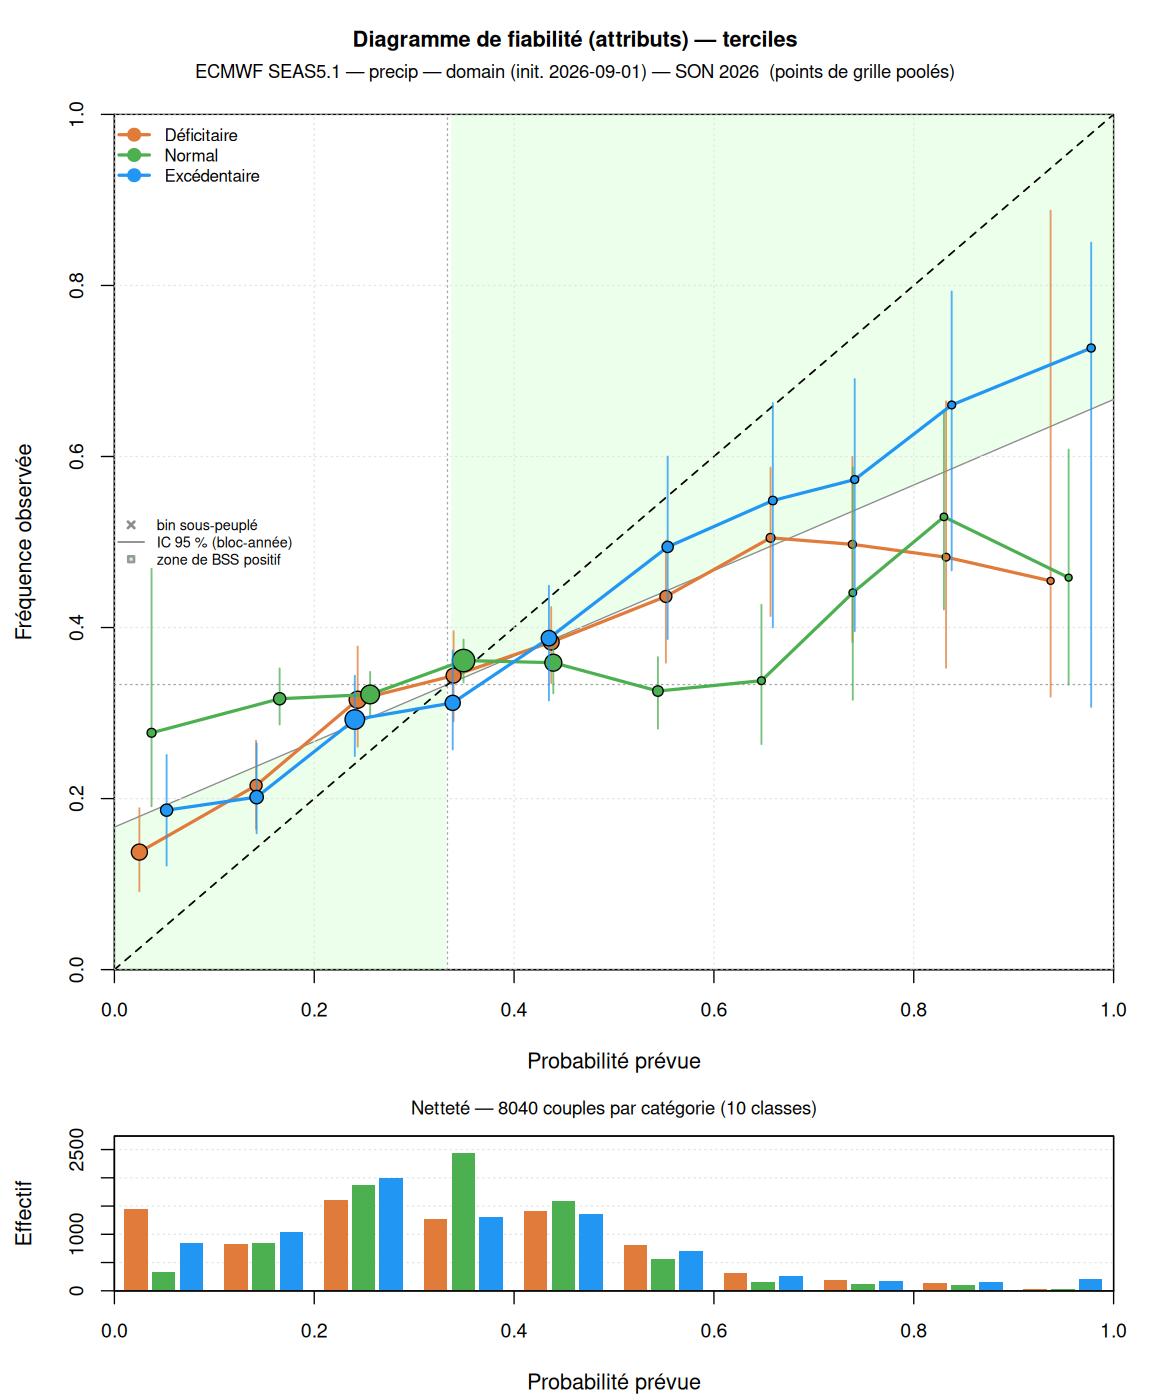

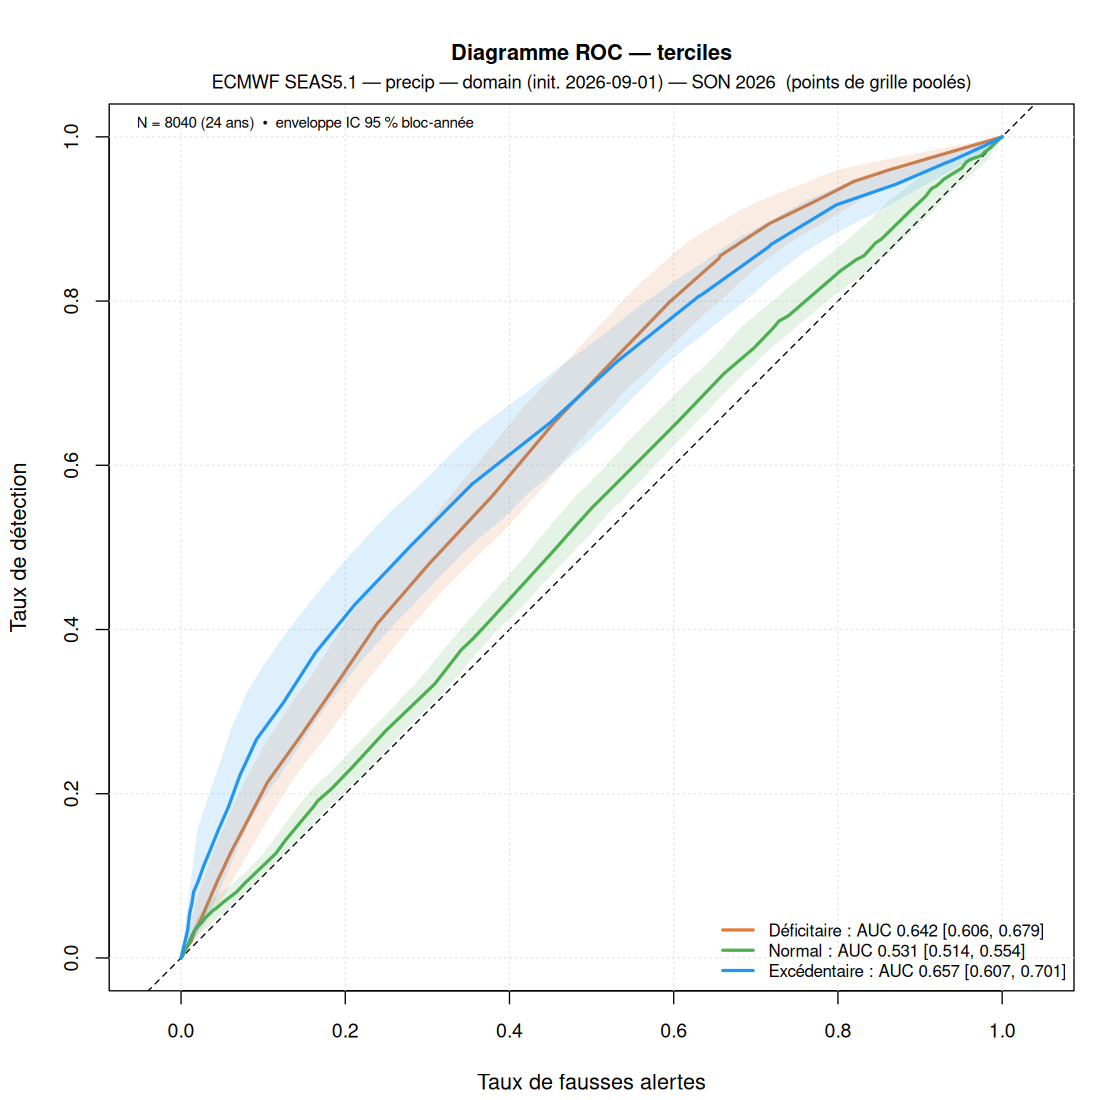

,category,n_pairs,base_rate,roc_area,roc_lo,roc_hi,reliability,resolution
21,BN,8040,0.317,0.642,0.606,0.679,0.011,0.012
22,NN,8040,0.344,0.531,0.514,0.554,0.015,0.001
23,AN,8040,0.339,0.657,0.607,0.701,0.007,0.017


In [10]:
from IPython.display import Image, display

d = OUT / "diagrams" / "c3s_ecmwf_precip" / "domain"
lab = son.label(cfg.init_date.year)
for name in (f"reliability_{lab}.png", f"roc_{lab}.png"):
    if (d / name).exists():
        display(Image(filename=str(d / name), width=620))
scores = pd.read_csv(d / "diagram_scores.csv")
display(scores[scores.period == lab][["category", "n_pairs", "base_rate", "roc_area",
                                      "roc_lo", "roc_hi", "reliability", "resolution"]].round(3))

## 8. L'éligibilité des modèles (§3.3)

Un modèle est retenu pour une variable, une échelle et une période lorsqu'il montre un skill
positif sur au moins 5 % du domaine, pour un critère **déterministe** (corrélation) **et** un
critère **probabiliste** (RPSS) ; un système sans membres n'est jugé que sur le critère
déterministe. Le registre produit ici alimente la pondération multimodèle (P6) et le masque de
skill des produits (P7).

In [11]:
elig = pd.read_csv(cfg.path_of("output_root") / "registry" / "models_eligibility.csv")
display(elig.pivot_table(index=["system", "model"], columns=["variable", "scale"],
                         values="periods_eligible", aggfunc="max").fillna("—"))

variable            precip                t2m          tmax               \
scale               decade month season month season decade month season   
system model                                                               
c3s    bom            21.0   7.0    4.0   6.0    4.0   21.0   7.0    5.0   
       cmcc           18.0   6.0    4.0   6.0    4.0   18.0   6.0    4.0   
       dwd            18.0   6.0    4.0   6.0    4.0   17.0   6.0    4.0   
       eccc           21.0   7.0    5.0   6.0    4.0   21.0   7.0    5.0   
       ecmwf          21.0   7.0    5.0   6.0    4.0   21.0   7.0    5.0   
       meteo_france   21.0   7.0    5.0   6.0    4.0   21.0   7.0    5.0   
       ukmo           21.0   7.0    5.0   6.0    4.0   21.0   7.0    5.0   
nmme   CFSv2             —  10.0    8.0  10.0    8.0      —     —      —   
       CanESM5           —  12.0   10.0  12.0   10.0      —     —      —   
       GEM5.2_NEMO       —  12.0   10.0  12.0   10.0      —     —      —   
       NASA_GEOS5v2      —   9.0    7.0   9.0    7.0      —     —      —   
       NCAR_CCSM4        —  12.0   10.0  12.0   10.0      —     —      —   
       NCAR_CESM1        —  12.0   10.0  12.0   10.0      —     —      —   

variable              tmin               
scale               decade month season  
system model                             
c3s    bom            21.0   7.0    5.0  
       cmcc           18.0   6.0    4.0  
       dwd            18.0   6.0    4.0  
       eccc           21.0   7.0    5.0  
       ecmwf          21.0   7.0    5.0  
       meteo_france   21.0   7.0    5.0  
       ukmo           21.0   7.0    5.0  
nmme   CFSv2             —     —      —  
       CanESM5           —     —      —  
       GEM5.2_NEMO       —     —      —  
       NASA_GEOS5v2      —     —      —  
       NCAR_CCSM4        —     —      —  
       NCAR_CESM1        —     —      —

## Ce qu'il faut retenir

1. Sans LOYO, un score est optimiste ; avec 24 années, l'effet n'est pas anecdotique.
2. Les catégories observées viennent de l'observation, les probabilités prévues de la
   climatologie du modèle : c'est ce qui rend le skill brut comparable d'un modèle à l'autre.
3. Les modèles bruts gardent du signal (ROC > 0,5) mais l'expriment mal (RPSS ≲ 0) : la
   calibration de la phase P3 a un travail précis à faire, et ce notebook en fixe la référence.
4. Une moyenne d'ensemble ne fournit pas de probabilité ; NMME est noté en déterministe
   seulement, et sur les mois et saisons seulement.
5. Deux implémentations indépendantes (Python et R) valent mieux qu'une.

**Suite :** phase P3 — correction de biais et calibration (régression logistique étendue, NGR),
notées avec exactement les mêmes scores et les mêmes diagrammes, pour que la comparaison avec ces
chiffres soit directe.